In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import os
import zipfile
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

In [ ]:
# Set dataset path
dataset_path = "/content/drive/My Drive/licenta/balanced"

# List available files
files = os.listdir(dataset_path)
print("Files in dataset:", files)

Files in dataset: ['test_balanced_questions.json', 'shortAnswer_translated.json', 'testdev_balanced_questions.json', 'val_balanced_questions.json', 'train_subset_balanced.json', 'val_subset_balanced.json', 'val_top500_filtered.json', 'test_top500_filtered.json', 'train_top500_subset.json', 'val_top500_subset.json', 'test_top500_subset.json', 'train_top500_100k.json', 'val_top500_balanced.json', 'test_top500_full.json', 'answer_vocab_top500.json', 'train_top100_shared_balanced.json', 'val_top100_shared_balanced.json', 'train_top100_cluster.json', 'val_top100_cluster.json', 'test_top100_shared_balanced.json', 'train_final.json']


In [ ]:
import os
import zipfile

zip_path = "/content/drive/My Drive/licenta/images.zip"  # Adjust if different name
extract_path = "/content/data"  # Folder where you'll unzip

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

image_dir = "/content/data/images"

# 1. List all files in /content/data
all_files = os.listdir(image_dir)

# 2. Filter by image extensions
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 3. Print stats
print(f"Total files in '{image_dir}': {len(all_files)}")
print(f"Total images (jpg/png/jpeg): {len(image_files)}")
print(f"First 5 images: {image_files[:5]}")

Total files in '/content/data/images': 148854
Total images (jpg/png/jpeg): 148854
First 5 images: ['2376592.jpg', '2362999.jpg', '2350530.jpg', '2334730.jpg', '1592704.jpg']


In [ ]:
dataset_path = "/content/drive/My Drive/vqa_clean/dataset_final"

def load_dataset(json_path):
    json_path = os.path.join(dataset_path, json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    df = pd.DataFrame.from_dict(data_json, orient="index")
    # df["question"] = df["question"]
    # df["answer"] = df["answer_clean"]
    # df["imageId"] = df["imageId"]
    return df

# train_df = load_dataset("train_with_caption.json")
# val_df = load_dataset("val_with_caption.json")
# test_df = load_dataset("test_with_caption.json")

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.0
!pip install --no-deps trl==0.22.2

In [ ]:
# from unsloth import FastVisionModel # FastLanguageModel for LLMs
# import torch

# # 4bit pre quantized models we support for 4x faster downloading + no OOMs.
# fourbit_models = [
#     "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
#     "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
#     "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
#     "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

#     "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
#     "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

#     "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
#     "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
#     "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

#     "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
#     "unsloth/llava-1.5-7b-hf-bnb-4bit",
# ] # More models at https://huggingface.co/unsloth

# model, tokenizer = FastVisionModel.from_pretrained(
#     "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit",
#     load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
#     use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
# )

In [ ]:
# model = FastVisionModel.get_peft_model(
#     model,
#     finetune_vision_layers     = True, # False if not finetuning vision layers
#     finetune_language_layers   = True, # False if not finetuning language layers
#     finetune_attention_modules = True, # False if not finetuning attention layers
#     finetune_mlp_modules       = True, # False if not finetuning MLP layers

#     r = 16,           # The larger, the higher the accuracy, but might overfit
#     lora_alpha = 16,  # Recommended alpha == r at least
#     lora_dropout = 0,
#     bias = "none",
#     random_state = 3407,
#     use_rslora = False,  # We support rank stabilized LoRA
#     loftq_config = None, # And LoftQ
#     # target_modules = "all-linear", # Optional now! Can specify a list if needed
# )

In [ ]:
import os
import torch
import pandas as pd
from PIL import Image
from datasets import Dataset
from unsloth import FastVisionModel
from trl import SFTTrainer

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.alignprop_trainer: Failed to import trl.trainer.alignprop_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
JITCallable._set_src() takes 1 positional argument but 2 were given
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Fa

In [ ]:
test_df = load_dataset("test_dataset_final_corrected_sure.json")

In [ ]:
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
image_root = "/content/data/images"
output_dir = "/content/preprocessed/train"  # unde vor fi salvate json-urile

In [ ]:
from tqdm import tqdm
from PIL import Image
import os

# Creează set cu toate ID-urile UNICE din test
unique_image_ids = set(example["imageId"] for example in test_dataset)

# Creează cache-ul doar pentru imaginile relevante
image_cache = {}

for image_id in tqdm(unique_image_ids, desc="Caching relevant test images"):
    filename = image_id + ".jpg"
    path = os.path.join(image_root, filename)
    try:
        image = Image.open(path).convert("RGB")
        image_cache[image_id] = image
    except Exception as e:
        print(f"⚠️ Failed to load {filename}: {e}")


Caching relevant test images: 100%|██████████| 398/398 [00:01<00:00, 242.78it/s]


In [ ]:
print(len(unique_image_ids))

398


In [ ]:
if True:
    from unsloth import FastVisionModel
    print("hree")
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "/content/drive/My Drive/licenta/new_llm/qwen_3VL_100k_ro_augments_image_32B_verybig_v1", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

hree
==((====))==  Unsloth 2026.1.4: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

model-00006-of-00007.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00005-of-00007.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

model-00007-of-00007.safetensors:   0%|          | 0.00/2.85G [00:00<?, ?B/s]

model-00002-of-00007.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00004-of-00007.safetensors:   0%|          | 0.00/4.76G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

In [ ]:
# def run_inference(model, tokenizer, image, question):
#     instruction = "Ești un asistent vizual care răspunde la întrebări despre imagine."

#     messages = [
#         {"role": "user", "content": [
#             {"type": "text", "text": instruction},
#             {"type": "image", "image": image},
#             {"type": "text", "text": f"Întrebare: {question} Răspuns:"}
#         ]}
#     ]

#     input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

#     inputs = tokenizer(
#         image,
#         input_text,
#         return_tensors="pt",
#         add_special_tokens=False,
#     ).to("cuda")

#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=32,
#         temperature=0.3,
#         top_p=0.8,
#         do_sample=False,
#     )

#     decoded = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
#     return decoded


In [ ]:
# def run_inference(model, tokenizer, image, question):
#     instruction = "Răspunde la întrebare cu un singur cuvânt. Nu folosi propoziții. Doar un cuvânt scurt, precis."

#     messages = [
#         {"role": "user", "content": [
#             {"type": "text", "text": instruction},
#             {"type": "image", "image": image},
#             {"type": "text", "text": f"Întrebare: {question} Răspuns:"}
#         ]}
#     ]

#     input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

#     inputs = tokenizer(
#         image,
#         input_text,
#         return_tensors="pt",
#         add_special_tokens=False,
#     ).to("cuda")

#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=32,
#         temperature=0.3,
#         top_p=0.8,
#         do_sample=False,
#     )

#     decoded = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
#     return decoded


In [ ]:
# def run_inference(model, tokenizer, image, question, caption_llava="", caption_blip="", yolo_att=""):
#     # Add context used in finetuning
#     extra_context = []
#     if caption_llava:
#         extra_context.append({"type": "text", "text": f"Descriere LLaVA: {caption_llava}"})
#     if caption_blip:
#         extra_context.append({"type": "text", "text": f"Descriere BLIP: {caption_blip}"})
#     if yolo_att:
#         extra_context.append({"type": "text", "text": f"Atribute YOLO: {yolo_att}"})

#     messages = [
#         {"role": "user", "content": [
#             {"type": "text", "text": f"Întrebare: {question}"},
#             {"type": "image", "image": image},
#             *extra_context
#         ]}
#     ]

#     input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

#     inputs = tokenizer(
#         image,
#         input_text,
#         return_tensors="pt",
#         add_special_tokens=False,
#     ).to("cuda")

#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=32,
#         temperature=1.5,
#         min_p = 0.1,
#         use_cache=True,
#     )

#     decoded = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
#     return decoded


In [ ]:
import re
import torch

def qwen_run_inference(model, tokenizer, image, question, caption=None):
    """
    Inference for Qwen2-VL (or other Qwen-VL) with optional caption.
    Returns a single-word answer (Romanian, as you designed).
    """
    # Base instruction
    instruction = "Răspunde la următoarea întrebare despre imagine cu un singur cuvânt."

    prompt_parts = []

    if caption and caption.strip():
        instruction = (
            "Având în vedere descrierea și imaginea, "
            "răspunde la următoarea întrebare cu un singur cuvânt."
        )
        prompt_parts.append(f"Descriere: {caption.strip()}")

    prompt_parts.append(instruction)
    prompt_parts.append(f"Întrebare: {question}")
    prompt_parts.append("Răspuns:")

    prompt = "\n\n".join(prompt_parts)

    # Qwen-style messages – same pattern as your LaTeX example
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},              # image is passed separately to tokenizer
                {"type": "text", "text": prompt}
            ],
        }
    ]

    # Turn into chat text
    input_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    # Encode image + text together
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    # Make sure model is in inference mode
    model.eval()
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=28,
            temperature=0.1,
            do_sample=False,
        )

    # Cut off the prompt
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]

    # Decode & force single-word answer
    final_answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    final_answer = final_answer.split('\n')[0].strip()
    final_answer = final_answer.split(' ')[0].strip()
    final_answer = re.sub(r'[^\w\s]', '', final_answer)

    return final_answer


In [ ]:
# import torch

# def run_inference(
#     model,
#     tokenizer,
#     image,
#     question: str,
#     max_new_tokens: int = 128,
#     temperature: float = 0.1,
#     min_p: float = 0.1,
# ):
#     """
#     Inference helper using the official FastVision / Qwen-style pattern,
#     adapted for Romanian and question-based prompting.
#     """

#     # Romanian instruction + your question
#     base_instruction = "Răspunde la următoarea întrebare despre imagine."
#     full_text = f"{base_instruction}\n\nÎntrebare: {question}\nRăspuns:"

#     # Build chat messages like in the official example
#     messages = [
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image"},
#                 {"type": "text", "text": full_text},
#             ],
#         }
#     ]

#     # Convert to chat text
#     input_text = tokenizer.apply_chat_template(
#         messages,
#         add_generation_prompt=True,
#         tokenize=False,
#     )

#     # Encode image + text together
#     inputs = tokenizer(
#         image,
#         input_text,
#         add_special_tokens=False,
#         return_tensors="pt",
#     ).to("cuda")

#     model.eval()
#     with torch.inference_mode():
#         outputs = model.generate(
#             **inputs,
#             max_new_tokens=max_new_tokens,
#             use_cache=True,
#             temperature=temperature,
#             min_p=min_p,
#         )

#     # Decode only newly generated tokens
#     input_len = inputs["input_ids"].shape[1]
#     generated_ids = outputs[0][input_len:]
#     text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

#     return text


In [ ]:
import torch

def run_inference(
    model,
    tokenizer,
    image,
    question: str,
    caption: str = None,  # <--- Added caption parameter
    max_new_tokens: int = 128,
    temperature: float = 0.1,
    min_p: float = 0.1,
):
    """
    Inference helper using the official FastVision / Qwen-style pattern,
    adapted for Romanian with optional Caption context.
    """

    base_instruction = "Răspunde la următoarea întrebare despre imagine."

    # --- Logic to include caption if it exists ---
    if caption and isinstance(caption, str) and len(caption.strip()) > 1:
        # We add the caption as context before the instruction
        full_text = f"Descriere context: {caption}\n\n{base_instruction}\n\nÎntrebare: {question}\nRăspuns:"
    else:
        # Standard prompt without caption
        full_text = f"{base_instruction}\n\nÎntrebare: {question}\nRăspuns:"

    # Build chat messages
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": full_text},
            ],
        }
    ]

    # Convert to chat text
    input_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    # Encode image + text together
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    model.eval()
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=temperature,
            min_p=min_p,
        )

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_len:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return text

In [ ]:
import torch

def run_inference_eng(
    model,
    tokenizer,
    image,
    question: str,
    max_new_tokens: int = 128,
    temperature: float = 0.1,
    min_p: float = 0.1,
):
    """
    Inference helper using the official FastVision / Qwen-style pattern,
    adapted for English question-based prompting.
    """

    # English instruction + your question
    base_instruction = "Answer the following question about the image."
    full_text = f"{base_instruction}\n\nQuestion: {question}\nAnswer:"

    # Build chat messages like in the official example
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": full_text},
            ],
        }
    ]

    # Convert to chat text
    input_text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    # Encode image + text together
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    model.eval()
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=temperature,
            min_p=min_p,
        )

    # Decode only newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_len:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return text

In [ ]:
# import json
# from tqdm import tqdm
# import os

# save_path = "/content/drive/My Drive/licenta/predictions/predictions_partial_qwen_finetunned.jsonl"
# FastVisionModel.for_inference(model)
# # Load existing imageId+question keys to skip
# processed_keys = set()
# if os.path.exists(save_path):
#     with open(save_path, "r", encoding="utf-8") as f:
#         for line in f:
#             try:
#                 record = json.loads(line)
#                 key = record["imageId"] + "|" + record["question"]
#                 processed_keys.add(key)
#             except: pass

# print(f"✅ Găsite deja {len(processed_keys)} exemple salvate")

# for example in tqdm(test_dataset, desc="Running inference"):
#     try:
#         image_id = example["imageId"]
#         question = example["question"]
#         key = image_id + "|" + question
#         if key in processed_keys:
#             continue

#         image = image_cache[image_id]
#         gt_answer = example.get("answer_clean", "")
#         pred = run_inference(model, tokenizer, image, question)

#         result = {
#             "imageId": image_id,
#             "question": question,
#             "gt_answer": gt_answer,
#             "prediction": pred
#         }

#         # 🔥 SCRIE IMEDIAT
#         with open(save_path, "a", encoding="utf-8") as f:
#             f.write(json.dumps(result, ensure_ascii=False) + "\n")

#         processed_keys.add(key)

#     except Exception as e:
#         print(f"⚠️ Eroare la {example.get('imageId', '??')}: {e}")


In [ ]:
import pandas as pd
import os

dataset_path = "/content/drive/My Drive/vqa_clean/dataset_final"

def load_dataset(json_path):
    """
    Loads the JSON data and converts the index (questionId) into a column.
    """
    json_path = os.path.join(dataset_path, json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)

    # orient="index" correctly uses your IDs as the index
    df = pd.DataFrame.from_dict(data_json, orient="index")

    # --- KEY CHANGE: Convert the index to a 'questionId' column ---
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'questionId'}, inplace=True)

    return df

# Now, load your test data using the updated function
test_df = load_dataset("test_dataset_final_corrected_sure.json")

print("✅ Data loaded into DataFrame. 'questionId' is now a column.")
print(test_df.head())

✅ Data loaded into DataFrame. 'questionId' is now a column.
  questionId                                           semantic  \
0  201307251  [{'operation': 'select', 'dependencies': [], '...   
1  201640614  [{'operation': 'select', 'dependencies': [], '...   
2  202225914  [{'operation': 'select', 'dependencies': [], '...   
3    2062325  [{'operation': 'select', 'dependencies': [], '...   
4  201303229  [{'operation': 'select', 'dependencies': [], '...   

                 entailed   equivalent  \
0                      []  [201307251]   
1  [201640613, 201640492]  [201640614]   
2             [202225913]  [202225914]   
3               [2062326]    [2062325]   
4             [201303228]  [201303229]   

                                            question  imageId  isBalanced  \
0                                      Este înnorat?  n161313        True   
1                                Cine poartă rochia?  n235859        True   
2  Ustensila de deasupra mesei arată curată și ne... 

In [ ]:
# import json
# from tqdm import tqdm
# import os

# save_path = "/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_and_corrected_final_iter"

# # ----------------------------
# # Load previously processed IDs
# # ----------------------------
# processed_keys = set()

# if os.path.exists(save_path):
#     with open(save_path, "r", encoding="utf-8") as f:
#         for line in f:
#             line = line.strip()
#             if not line:
#                 continue
#             try:
#                 record = json.loads(line)
#                 processed_keys.add(record["questionId"])
#             except:
#                 # Skip malformed JSON lines
#                 continue

# print(f"✅ Already processed: {len(processed_keys)} examples.")


# # ----------------------------
# # Main inference loop
# # ----------------------------
# with open(save_path, "a", encoding="utf-8") as outfile:
#     for index, row in tqdm(test_df.iterrows(), total=test_df.shape[0], desc="Running inference"):

#         try:
#             qid = row["questionId"]

#             # Skip processed examples
#             if qid in processed_keys:
#                 continue

#             image_id = row["imageId"]
#             question = row["corrected_question"]
#             image = image_cache[str(image_id)]
#             gt_answer = row.get("corrected_answer", "")

#             # Run model inference (MATCHES FUNCTION SIGNATURE NOW)
#             pred = run_inference(
#                 model,
#                 tokenizer,
#                 image=image,
#                 question=question,
#             )

#             # Build result record
#             record = {
#                 "questionId": qid,
#                 "imageId": image_id,
#                 "question": question,
#                 "gt_answer": gt_answer,
#                 "prediction": pred,
#             }

#             # Save immediately
#             outfile.write(json.dumps(record, ensure_ascii=False) + "\n")
#             outfile.flush()

#             processed_keys.add(qid)

#         except Exception as e:
#             print(f"⚠️ Error on Question {qid}: {e}")
#             continue

# print("🎉 Done!")


✅ Already processed: 0 examples.


Running inference: 100%|██████████| 12578/12578 [2:46:54<00:00,  1.26it/s]

🎉 Done!


In [ ]:
import json
from tqdm import tqdm
import os
import pandas as pd # Ensure pandas is imported to check for NA

# Update path if you want to save to a different file for the captioned version
save_path = "/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_32b_wiht_images_aug.json"

# ----------------------------
# Load previously processed IDs
# ----------------------------
processed_keys = set()

if os.path.exists(save_path):
    with open(save_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
                processed_keys.add(record["questionId"])
            except:
                continue

print(f"✅ Already processed: {len(processed_keys)} examples.")


# ----------------------------
# Main inference loop
# ----------------------------
with open(save_path, "a", encoding="utf-8") as outfile:
    # Assuming test_df is already loaded and contains 'caption_llava'
    for index, row in tqdm(test_df.iterrows(), total=test_df.shape[0], desc="Running inference"):

        try:
            qid = row["questionId"]

            # Skip processed examples
            if qid in processed_keys:
                continue

            image_id = row["imageId"]
            question = row["corrected_question"]
            image = image_cache[str(image_id)]
            gt_answer = row.get("corrected_answer", "")

            # --- EXTRACT CAPTION ---
            # We use .get() and check for NaN/None to avoid errors
            # caption_raw = row.get("caption_llava", "")
            # caption = caption_raw if pd.notna(caption_raw) else ""
            caption = None

            # Run model inference (PASSING CAPTION NOW)
            pred = run_inference(
                model,
                tokenizer,
                image=image,
                question=question,
                caption=caption  # <--- Passing the caption here
            )

            # Build result record
            record = {
                "questionId": qid,
                "imageId": image_id,
                "question": question,
                "caption_used": caption, # Useful to save what caption was used
                "gt_answer": gt_answer,
                "prediction": pred,
            }

            # Save immediately
            outfile.write(json.dumps(record, ensure_ascii=False) + "\n")
            outfile.flush()

            processed_keys.add(qid)

        except Exception as e:
            print(f"⚠️ Error on Question {qid}: {e}")
            continue

print("🎉 Done!")

✅ Already processed: 0 examples.


Running inference: 100%|██████████| 12578/12578 [4:11:01<00:00,  1.20s/it]

🎉 Done!


In [ ]:
!pip install rouge-score
!pip install bert-score
!pip install nltk


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7d3706012b9029d92b282509f07e66f82b85baa13935272e71b08c939420e235
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
import re
import unicodedata

def clean_text(text: str):
    if text is None:
        return ""

    # lowercase
    text = text.lower().strip()

    # normalize Romanian diacritics
    text = unicodedata.normalize("NFC", text)

    # collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


In [ ]:
import json

file_path = "/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro.json"

predictions = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            predictions.append(json.loads(line))
        except:
            print("Skipping malformed line.")


In [ ]:
gt_answers = [clean_text(p["gt_answer"]) for p in predictions]
pred_answers = [clean_text(p["prediction"]) for p in predictions]


In [ ]:
print(list(zip(gt_answers[:10], pred_answers[:10])))


[('nu', 'nu'), ('femei', 'doamnă'), ('nu', 'da'), ('da', 'da'), ('mic de statura', 'mic'), ('tastatură', 'monitorul computerului'), ('ocean', 'ocean'), ('roșu', 'roșu'), ('maro', 'maro'), ('draperii', 'cuvertură')]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer
import bert_score

# === Accuracy & F1 ===
accuracy = accuracy_score(gt_answers, pred_answers)
f1 = f1_score(gt_answers, pred_answers, average='weighted')

# === BLEU ===
bleu = corpus_bleu(
    [[ref.split()] for ref in gt_answers],
    [hyp.split() for hyp in pred_answers]
)

# === ROUGE ===
scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
rouge_scores = [scorer.score(ref, pred) for ref, pred in zip(gt_answers, pred_answers)]

def avg_rouge(key):
    return sum(s[key].fmeasure for s in rouge_scores) / len(rouge_scores)

# === BertScore (Romanian language model) ===
P, R, F1 = bert_score.score(pred_answers, gt_answers, lang="ro")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
results = {
    "accuracy": round(accuracy, 4),
    "f1_weighted": round(f1, 4),
    "bleu": round(bleu, 4),
    "rouge-1": round(avg_rouge("rouge1"), 4),
    "rouge-2": round(avg_rouge("rouge2"), 4),
    "rouge-l": round(avg_rouge("rougeL"), 4),
    "bertscore_f1": round(F1.mean().item(), 4),
}

print("📊 Rezultate evaluare:")
for k, v in results.items():
    print(f"{k}: {v}")


📊 Rezultate evaluare:
accuracy: 0.4754
f1_weighted: 0.4774
bleu: 0.0069
rouge-1: 0.4903
rouge-2: 0.0467
rouge-l: 0.4902
bertscore_f1: 0.8823


In [ ]:
import json
import re
from sklearn.metrics import accuracy_score, f1_score
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer
import bert_score

# === Încarcă predicțiile ===
path = "/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro.json"
predictions = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            predictions.append(json.loads(line))
        except:
            continue

In [ ]:
# === Curățare predicții ===
def clean_prediction(pred):
    match = re.search(r"Răspuns:\s*assistant\s*\n*\s*(.*)", pred, re.IGNORECASE)
    if match:
        return match.group(1).strip().strip(".").lower()
    return pred.strip().strip(".").lower()

def clean_answer(ans):
    return ans.strip().strip(".").lower()

In [ ]:
# gt_answers = [clean_answer(p["gt_answer"]) for p in predictions]
# pred_answers = [clean_prediction(p["prediction"]) for p in predictions]

# # === Accuracy și F1 ===
# accuracy = accuracy_score(gt_answers, pred_answers)
# f1 = f1_score(gt_answers, pred_answers, average='micro')

# # === BLEU ===
# bleu = corpus_bleu([[ref.split()] for ref in gt_answers], [hyp.split() for hyp in pred_answers])


In [ ]:
# # === ROUGE ===
# scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
# rouge_scores = [scorer.score(ref, pred) for ref, pred in zip(gt_answers, pred_answers)]

# # Medii ROUGE
# def avg_rouge(key):
#     return sum([score[key].fmeasure for score in rouge_scores]) / len(rouge_scores)

# # === BERTScore ===
# P, R, F1 = bert_score.score(pred_answers, gt_answers, lang="ro")

In [ ]:
import json, numpy as np, torch, nltk, re
from collections import Counter
from sklearn.metrics import classification_report
from bert_score import score as bert_scorer
from sentence_transformers import SentenceTransformer, util
from nltk.corpus import wordnet

# One-time NLTK setup
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# -----------------------------
# Romanian cleaning
# -----------------------------
def clean_text(s: str) -> str:
    if not s:
        return ""
    s = s.strip().lower()
    s = re.sub(r"[^\wăâîșț ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# -----------------------------
# WUPS helpers (Romanian)
# -----------------------------
_OPP_SETS = [
    {"da", "nu"},
    {"stânga", "stanga", "dreapta"},
]

def _wup_tok(a, b, th=0.925):
    a, b = a.lower(), b.lower()
    if a == b:
        return 1.0
    if frozenset((a, b)) in _OPP_SETS:
        return 0.0
    s1, s2 = wordnet.synsets(a, lang="ron"), wordnet.synsets(b, lang="ron")
    if s1 and s2:
        best = max((x.wup_similarity(y) or 0) for x in s1 for y in s2)
        return best if best >= th else 0.1 * best
    return 0.0

def wup_ro(ans_a, ans_b, th=0.925):
    ta, tb = ans_a.lower().split(), ans_b.lower().split()
    if not ta or not tb:
        return 0.0
    scores = [max(_wup_tok(x, y, th) for y in tb) for x in ta]
    scores += [max(_wup_tok(y, x, th) for x in ta) for y in tb]
    return float(np.mean(scores))

# -----------------------------
# MAIN evaluator
# -----------------------------
def evaluate_vqa(pred_path: str, top_k_freq: int = 10):

    # --- Load JSONL ---
    y_true, y_pred = [], []
    with open(pred_path, encoding="utf-8") as fh:
        for ln in fh:
            o = json.loads(ln)
            y_true.append(clean_text(o["gt_answer"]))
            y_pred.append(clean_text(o["prediction"]))

    assert len(y_true) == len(y_pred)
    n = len(y_true)

    # --- Classic metrics ---
    report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    acc = report["accuracy"]
    f1w = report["weighted avg"]["f1-score"]
    prw = report["weighted avg"]["precision"]
    rew = report["weighted avg"]["recall"]

    # --- WUPS ---
    wups = np.mean([wup_ro(gt, pr) for gt, pr in zip(y_true, y_pred)])

    # --- Masks ---
    mask_bin = [a in {"da", "nu"} for a in y_true]
    mask_lr  = [a in {"stânga", "stanga", "dreapta"} for a in y_true]
    mask_non = [not(b or l) for b, l in zip(mask_bin, mask_lr)]

    # --- BERTScore (non-binary) ---
    pred_non = [y_pred[i] for i,m in enumerate(mask_non) if m]
    true_non = [y_true[i] for i,m in enumerate(mask_non) if m]

    if len(true_non) > 0:
        _, _, F1 = bert_scorer(
            pred_non,
            true_non,
            model_type="dumitrescustefan/bert-base-romanian-cased-v1",
            num_layers=12,
            batch_size=64,
            verbose=False,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )
        bert_f1 = F1.mean().item()
    else:
        bert_f1 = float("nan")

    # --- Cosine similarity (sentence transformers) ---
    if len(true_non) > 0:
        st = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
        e_true = st.encode(true_non, convert_to_tensor=True, normalize_embeddings=True)
        e_pred = st.encode(pred_non, convert_to_tensor=True, normalize_embeddings=True)
        cos = util.cos_sim(e_true, e_pred).diagonal()
        cos_mean = float(cos.mean())
        cos_acc  = float((cos >= 0.80).float().mean())
    else:
        cos_mean = cos_acc = float("nan")

    # --- Per-group accuracies ---
    def acc_mask(mask):
        items = [p == g for p,g,m in zip(y_pred, y_true, mask) if m]
        return float(np.mean(items)) if items else float("nan")

    acc_bin = acc_mask(mask_bin)
    acc_lr  = acc_mask(mask_lr)
    acc_oth = acc_mask(mask_non)

    # --- Frequency table ---
    STOP = {"da", "nu", "stânga", "stanga", "dreapta"}
    freq_other = Counter(a for a in y_true if a not in STOP).most_common(top_k_freq)

    # --- PRINT RESULTS ---
    print("\n======  METRICS  ======")
    print(f"Samples                         : {n}")
    print(f"Accuracy                        : {acc:.4f}")
    print(f"F1 weighted                     : {f1w:.4f}")
    print(f"Precision weighted              : {prw:.4f}")
    print(f"Recall weighted                 : {rew:.4f}")
    print(f"WUPS-RO mean (all)              : {wups:.4f}")
    print(f"BERTScore F1 (non-binary)       : {bert_f1:.4f}")
    print(f"Cosine mean (non-binary)        : {cos_mean:.4f}")
    print(f"Cosine acc @0.80 (non-binary)   : {cos_acc:.4f}")
    print(f"Accuracy da/nu                  : {acc_bin:.4f}")
    print(f"Accuracy stânga|dreapta         : {acc_lr:.4f}")
    print(f"Accuracy other                  : {acc_oth:.4f}")

    print(f"\nTop {top_k_freq} most frequent *other* answers:")
    for ans, ct in freq_other:
        print(f"   {ans:<15s}: {ct}")

    # Return as dictionary
    return {
        "samples": n,
        "accuracy": acc,
        "f1_weighted": f1w,
        "precision_weighted": prw,
        "recall_weighted": rew,
        "wups_mean": wups,
        "bert_f1_non": bert_f1,
        "cosine_mean_non": cos_mean,
        "cosine_acc80_non": cos_acc,
        "acc_da_nu": acc_bin,
        "acc_left_right": acc_lr,
        "acc_other": acc_oth,
        "top_other_freq": freq_other,
    }


In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_32b_wiht_images_aug.json")

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.6104
F1 weighted                     : 0.5932
Precision weighted              : 0.6221
Recall weighted                 : 0.6104
WUPS-RO mean (all)              : 0.6466
BERTScore F1 (non-binary)       : 0.8650
Cosine mean (non-binary)        : 0.7566
Cosine acc @0.80 (non-binary)   : 0.5436
Accuracy da/nu                  : 0.7929
Accuracy stânga|dreapta         : 0.9107
Accuracy other                  : 0.4745

Top 10 most frequent *other* answers:
   mic            : 162
   femeie         : 161
   scaun          : 145
   negru          : 138
   masa           : 136
   om             : 123
   alb            : 112
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.6104309111146446,
 'f1_weighted': 0.5932437070043628,
 'precision_weighted': 0.6220521139486003,
 'recall_weighted': 0.6104309111146446,
 'wups_mean': np.float64(0.6466323506280705),
 'bert_f1_non': 0.8649968504905701,
 'cosine_mean_non': 0.756621778011322,
 'cosine_acc80_non': 0.543633222579956,
 'acc_da_nu': 0.7929281767955801,
 'acc_left_right': 0.9107142857142857,
 'acc_other': 0.4745192954148178,
 'top_other_freq': [('mic', 162),
  ('femeie', 161),
  ('scaun', 145),
  ('negru', 138),
  ('masa', 136),
  ('om', 123),
  ('alb', 112),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
# /content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_and_corrected_final_iter_WITH_CAPTIONS.jsonl


evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_and_corrected_final_iter_WITH_CAPTIONS.jsonl")


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.5557
F1 weighted                     : 0.5353
Precision weighted              : 0.5626
Recall weighted                 : 0.5557
WUPS-RO mean (all)              : 0.5938
BERTScore F1 (non-binary)       : 0.8516
Cosine mean (non-binary)        : 0.7266
Cosine acc @0.80 (non-binary)   : 0.4894
Accuracy da/nu                  : 0.7556
Accuracy stânga|dreapta         : 0.8929
Accuracy other                  : 0.4062

Top 10 most frequent *other* answers:
   mic            : 162
   femeie         : 161
   scaun          : 145
   negru          : 138
   masa           : 136
   om             : 123
   alb            : 112
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.5557322308793131,
 'f1_weighted': 0.5353494444231901,
 'precision_weighted': 0.5626045682798217,
 'recall_weighted': 0.5557322308793131,
 'wups_mean': np.float64(0.593797740728839),
 'bert_f1_non': 0.8516432046890259,
 'cosine_mean_non': 0.7266241312026978,
 'cosine_acc80_non': 0.48944467306137085,
 'acc_da_nu': 0.7555801104972376,
 'acc_left_right': 0.8928571428571429,
 'acc_other': 0.4062121823315853,
 'top_other_freq': [('mic', 162),
  ('femeie', 161),
  ('scaun', 145),
  ('negru', 138),
  ('masa', 136),
  ('om', 123),
  ('alb', 112),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
# qwen_100k_augmentend_and_corrected_final_iter

evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_augmentend_and_corrected_final_iter")

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.5672
F1 weighted                     : 0.5427
Precision weighted              : 0.5625
Recall weighted                 : 0.5672
WUPS-RO mean (all)              : 0.6046
BERTScore F1 (non-binary)       : 0.8559
Cosine mean (non-binary)        : 0.7260
Cosine acc @0.80 (non-binary)   : 0.4933
Accuracy da/nu                  : 0.7719
Accuracy stânga|dreapta         : 0.9026
Accuracy other                  : 0.4148

Top 10 most frequent *other* answers:
   mic            : 162
   femeie         : 161
   scaun          : 145
   negru          : 138
   masa           : 136
   om             : 123
   alb            : 112
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.5671807918588011,
 'f1_weighted': 0.5427443557288594,
 'precision_weighted': 0.5624727066586682,
 'recall_weighted': 0.5671807918588011,
 'wups_mean': np.float64(0.6045826339894946),
 'bert_f1_non': 0.8559364676475525,
 'cosine_mean_non': 0.7259619832038879,
 'cosine_acc80_non': 0.49334409832954407,
 'acc_da_nu': 0.7719337016574586,
 'acc_left_right': 0.9025974025974026,
 'acc_other': 0.41481780287750436,
 'top_other_freq': [('mic', 162),
  ('femeie', 161),
  ('scaun', 145),
  ('negru', 138),
  ('masa', 136),
  ('om', 123),
  ('alb', 112),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_32B")

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.6225
F1 weighted                     : 0.6060
Precision weighted              : 0.6298
Recall weighted                 : 0.6225
WUPS-RO mean (all)              : 0.6564
BERTScore F1 (non-binary)       : 0.8681
Cosine mean (non-binary)        : 0.7602
Cosine acc @0.80 (non-binary)   : 0.5571
Accuracy da/nu                  : 0.8066
Accuracy stânga|dreapta         : 0.9156
Accuracy other                  : 0.4862

Top 10 most frequent *other* answers:
   femeie         : 161
   scaun          : 145
   masa           : 136
   om             : 123
   mic            : 116
   alb            : 112
   negru          : 108
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.6225155032596598,
 'f1_weighted': 0.6059931123583678,
 'precision_weighted': 0.6298196499527884,
 'recall_weighted': 0.6225155032596598,
 'wups_mean': np.float64(0.6564329951760278),
 'bert_f1_non': 0.8680533766746521,
 'cosine_mean_non': 0.7602267265319824,
 'cosine_acc80_non': 0.5570794939994812,
 'acc_da_nu': 0.8066298342541437,
 'acc_left_right': 0.9155844155844156,
 'acc_other': 0.4862175608444265,
 'top_other_freq': [('femeie', 161),
  ('scaun', 145),
  ('masa', 136),
  ('om', 123),
  ('mic', 116),
  ('alb', 112),
  ('negru', 108),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:


evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_250k_eng_low_temp.json")

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.6571
F1 weighted                     : 0.6448
Precision weighted              : 0.6778
Recall weighted                 : 0.6571
WUPS-RO mean (all)              : 0.6719
BERTScore F1 (non-binary)       : 0.8615
Cosine mean (non-binary)        : 0.8388
Cosine acc @0.80 (non-binary)   : 0.7031
Accuracy da/nu                  : nan
Accuracy stânga|dreapta         : nan
Accuracy other                  : 0.6571

Top 10 most frequent *other* answers:
   yes            : 2328
   no             : 2197
   right          : 328
   left           : 288
   woman          : 152
   chair          : 143
   table          : 136
   man            : 123
   small          : 115
   white          : 112


{'samples': 12578,
 'accuracy': 0.6570996978851964,
 'f1_weighted': 0.6447506921169971,
 'precision_weighted': 0.6778295788547569,
 'recall_weighted': 0.6570996978851964,
 'wups_mean': np.float64(0.6719313934860061),
 'bert_f1_non': 0.8615158796310425,
 'cosine_mean_non': 0.8388267159461975,
 'cosine_acc80_non': 0.7031324505805969,
 'acc_da_nu': nan,
 'acc_left_right': nan,
 'acc_other': 0.6570996978851964,
 'top_other_freq': [('yes', 2328),
  ('no', 2197),
  ('right', 328),
  ('left', 288),
  ('woman', 152),
  ('chair', 143),
  ('table', 136),
  ('man', 123),
  ('small', 115),
  ('white', 112)]}

In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_low_temp_v2.json")


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.5751
F1 weighted                     : 0.5561
Precision weighted              : 0.5821
Recall weighted                 : 0.5751
WUPS-RO mean (all)              : 0.6097
BERTScore F1 (non-binary)       : 0.8560
Cosine mean (non-binary)        : 0.7305
Cosine acc @0.80 (non-binary)   : 0.5042
Accuracy da/nu                  : 0.7766
Accuracy stânga|dreapta         : 0.8994
Accuracy other                  : 0.4256

Top 10 most frequent *other* answers:
   femeie         : 161
   scaun          : 145
   masa           : 136
   om             : 123
   mic            : 116
   alb            : 112
   negru          : 108
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.5750516775321991,
 'f1_weighted': 0.556084683726454,
 'precision_weighted': 0.5821491954054179,
 'recall_weighted': 0.5750516775321991,
 'wups_mean': np.float64(0.6096829505124541),
 'bert_f1_non': 0.8559769988059998,
 'cosine_mean_non': 0.7304897904396057,
 'cosine_acc80_non': 0.504235565662384,
 'acc_da_nu': 0.7765745856353591,
 'acc_left_right': 0.8993506493506493,
 'acc_other': 0.4255748285599032,
 'top_other_freq': [('femeie', 161),
  ('scaun', 145),
  ('masa', 136),
  ('om', 123),
  ('mic', 116),
  ('alb', 112),
  ('negru', 108),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_low_temp_0.1_temp.json")



======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.5806
F1 weighted                     : 0.5599
Precision weighted              : 0.5860
Recall weighted                 : 0.5806
WUPS-RO mean (all)              : 0.6157
BERTScore F1 (non-binary)       : 0.8577
Cosine mean (non-binary)        : 0.7325
Cosine acc @0.80 (non-binary)   : 0.5075
Accuracy da/nu                  : 0.7830
Accuracy stânga|dreapta         : 0.9042
Accuracy other                  : 0.4307

Top 10 most frequent *other* answers:
   femeie         : 161
   scaun          : 145
   masa           : 136
   om             : 123
   mic            : 116
   alb            : 112
   negru          : 108
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.5806169502305613,
 'f1_weighted': 0.5598913959317939,
 'precision_weighted': 0.5860361366642481,
 'recall_weighted': 0.5806169502305613,
 'wups_mean': np.float64(0.6156605527081864),
 'bert_f1_non': 0.8576532006263733,
 'cosine_mean_non': 0.7325197458267212,
 'cosine_acc80_non': 0.5074626803398132,
 'acc_da_nu': 0.7829834254143646,
 'acc_left_right': 0.9042207792207793,
 'acc_other': 0.43068441575904265,
 'top_other_freq': [('femeie', 161),
  ('scaun', 145),
  ('masa', 136),
  ('om', 123),
  ('mic', 116),
  ('alb', 112),
  ('negru', 108),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_fullimage.json")



======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.4903
F1 weighted                     : 0.4909
Precision weighted              : 0.5292
Recall weighted                 : 0.4903
WUPS-RO mean (all)              : 0.5303
BERTScore F1 (non-binary)       : 0.8228
Cosine mean (non-binary)        : 0.6836
Cosine acc @0.80 (non-binary)   : 0.4077
Accuracy da/nu                  : 0.7145
Accuracy stânga|dreapta         : 0.8766
Accuracy other                  : 0.3219

Top 10 most frequent *other* answers:
   femeie         : 161
   scaun          : 145
   masa           : 136
   om             : 123
   mic            : 116
   alb            : 112
   negru          : 108
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.49030052472571156,
 'f1_weighted': 0.490936030969188,
 'precision_weighted': 0.529174377928879,
 'recall_weighted': 0.49030052472571156,
 'wups_mean': np.float64(0.5303136063623124),
 'bert_f1_non': 0.8228041529655457,
 'cosine_mean_non': 0.6836168766021729,
 'cosine_acc80_non': 0.4076912999153137,
 'acc_da_nu': 0.714475138121547,
 'acc_left_right': 0.8766233766233766,
 'acc_other': 0.3219039935457846,
 'top_other_freq': [('femeie', 161),
  ('scaun', 145),
  ('masa', 136),
  ('om', 123),
  ('mic', 116),
  ('alb', 112),
  ('negru', 108),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

In [ ]:
evaluate_vqa("/content/drive/My Drive/licenta/balanced_llms/reports/qwen_250k_normal_final.json")



======  METRICS  ======
Samples                         : 12578
Accuracy                        : 0.5681
F1 weighted                     : 0.5461
Precision weighted              : 0.5638
Recall weighted                 : 0.5681
WUPS-RO mean (all)              : 0.6074
BERTScore F1 (non-binary)       : 0.8496
Cosine mean (non-binary)        : 0.7303
Cosine acc @0.80 (non-binary)   : 0.4956
Accuracy da/nu                  : 0.7649
Accuracy stânga|dreapta         : 0.8799
Accuracy other                  : 0.4225

Top 10 most frequent *other* answers:
   femeie         : 161
   scaun          : 145
   masa           : 136
   om             : 123
   mic            : 116
   alb            : 112
   negru          : 108
   canapea        : 105
   băiat          : 104
   mare           : 88


{'samples': 12578,
 'accuracy': 0.5680553347114009,
 'f1_weighted': 0.5460976236155552,
 'precision_weighted': 0.5638052953394926,
 'recall_weighted': 0.5680553347114009,
 'wups_mean': np.float64(0.6073855198980745),
 'bert_f1_non': 0.8495680093765259,
 'cosine_mean_non': 0.7302645444869995,
 'cosine_acc80_non': 0.4956299662590027,
 'acc_da_nu': 0.7648618784530387,
 'acc_left_right': 0.8798701298701299,
 'acc_other': 0.42248218367621354,
 'top_other_freq': [('femeie', 161),
  ('scaun', 145),
  ('masa', 136),
  ('om', 123),
  ('mic', 116),
  ('alb', 112),
  ('negru', 108),
  ('canapea', 105),
  ('băiat', 104),
  ('mare', 88)]}

#zero shot

In [ ]:
gt_answers = [clean_answer(p["gt_answer"]) for p in predictions]
pred_answers = [clean_prediction(p["prediction"]) for p in predictions]

# === Metrics ===
accuracy = accuracy_score(gt_answers, pred_answers)
f1 = f1_score(gt_answers, pred_answers, average='weighted')  # 🟢 weighted!

bleu = corpus_bleu([[ref.split()] for ref in gt_answers], [hyp.split() for hyp in pred_answers])

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = [scorer.score(ref, pred) for ref, pred in zip(gt_answers, pred_answers)]
def avg_rouge(key):
    return sum([score[key].fmeasure for score in rouge_scores]) / len(rouge_scores)

P, R, F1 = bert_score.score(pred_answers, gt_answers, lang="ro")

# === Final results ===
results = {
    "accuracy": round(accuracy, 4),
    "f1_weighted": round(f1, 4),
    "bleu": round(bleu, 4),
    "rouge-1": round(avg_rouge("rouge1"), 4),
    "rouge-2": round(avg_rouge("rouge2"), 4),
    "rouge-l": round(avg_rouge("rougeL"), 4),
    "bertscore_f1": round(F1.mean().item(), 4)
}

print("📊 Rezultate evaluare:")
for k, v in results.items():
    print(f"{k}: {v}")

#fine tune

In [ ]:
gt_answers = [clean_answer(p["gt_answer"]) for p in predictions]
pred_answers = [clean_prediction(p["prediction"]) for p in predictions]

# === Metrics ===
accuracy = accuracy_score(gt_answers, pred_answers)
f1 = f1_score(gt_answers, pred_answers, average='weighted')  # 🟢 weighted!

bleu = corpus_bleu([[ref.split()] for ref in gt_answers], [hyp.split() for hyp in pred_answers])

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_scores = [scorer.score(ref, pred) for ref, pred in zip(gt_answers, pred_answers)]
def avg_rouge(key):
    return sum([score[key].fmeasure for score in rouge_scores]) / len(rouge_scores)

P, R, F1 = bert_score.score(pred_answers, gt_answers, lang="ro")

# === Final results ===
results = {
    "accuracy": round(accuracy, 4),
    "f1_weighted": round(f1, 4),
    "bleu": round(bleu, 4),
    "rouge-1": round(avg_rouge("rouge1"), 4),
    "rouge-2": round(avg_rouge("rouge2"), 4),
    "rouge-l": round(avg_rouge("rougeL"), 4),
    "bertscore_f1": round(F1.mean().item(), 4)
}

print("📊 Rezultate evaluare:")
for k, v in results.items():
    print(f"{k}: {v}")

In [ ]:
print("📊 Rezultate evaluare:")
for k, v in results.items():
    print(f"{k}: {v}")

In [ ]:
pip install rouge-score nltk bert-score sentence-transformers scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.3 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b5f652eb14ffa548c4acca84770f6ab3ef216c61261dcd06ec66af260c255219
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
pip install rouge-score nltk bert-score sentence-transformers scikit-learn

In [ ]:
import json
import re
import numpy as np
import torch
import nltk
from collections import Counter
from sklearn.metrics import accuracy_score

# Generative Metrics
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_scorer
from sentence_transformers import SentenceTransformer, util

# NLTK Setup
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)

# -----------------------------
# 1. Text Cleaning (Romanian)
# -----------------------------
def clean_text(s: str) -> str:
    """Standardizes Romanian text for fair comparison."""
    if not s:
        return ""
    s = s.strip().lower()
    # Keep alphanumeric + Romanian chars
    s = re.sub(r"[^\wăâîșț ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# -----------------------------
# 2. Helper: SQuAD-style F1 (Token Overlap)
# -----------------------------
def compute_f1_token_single(a_gold, a_pred):
    """Computes token-level F1 score (Precision/Recall of words)."""
    gold_toks = a_gold.split()
    pred_toks = a_pred.split()

    common = Counter(gold_toks) & Counter(pred_toks)
    num_same = sum(common.values())

    if len(gold_toks) == 0 or len(pred_toks) == 0:
        # If both empty, 1.0; if one empty, 0.0
        return int(gold_toks == pred_toks)

    if num_same == 0:
        return 0.0

    precision = 1.0 * num_same / len(pred_toks)
    recall = 1.0 * num_same / len(gold_toks)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

# -----------------------------
# 3. Helper: Metrics Calculation
# -----------------------------
def calculate_generative_metrics(y_true, y_pred):
    """Calculates ROUGE, BLEU, METEOR, and Token F1."""

    # --- A. BLEU-4 (Corpus Level) ---
    # References must be list of lists: [[['cat', 'sat']], [['dog', 'ran']]]
    refs_tokens = [[t.split()] for t in y_true]
    hyps_tokens = [p.split() for p in y_pred]

    # Smoothing is important for short VQA answers
    cc = SmoothingFunction()
    bleu4 = corpus_bleu(refs_tokens, hyps_tokens, smoothing_function=cc.method3)

    # --- B. ROUGE (L & 1) ---
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    rouge_1_scores = []
    rouge_l_scores = []

    # --- C. METEOR & Token F1 ---
    meteor_scores = []
    f1_token_scores = []

    for gt, pr in zip(y_true, y_pred):
        # ROUGE
        scores = scorer.score(gt, pr)
        rouge_1_scores.append(scores['rouge1'].fmeasure)
        rouge_l_scores.append(scores['rougeL'].fmeasure)

        # METEOR (Expects tokenized lists, handles stemming better)
        # Note: NLTK Meteor defaults to English stemmers, but useful for basic overlap
        meteor_scores.append(meteor_score([gt.split()], pr.split()))

        # Token F1
        f1_token_scores.append(compute_f1_token_single(gt, pr))

    return {
        "bleu4": bleu4,
        "rouge1": np.mean(rouge_1_scores),
        "rougeL": np.mean(rouge_l_scores),
        "meteor": np.mean(meteor_scores),
        "f1_token": np.mean(f1_token_scores)
    }

# -----------------------------
# 4. MAIN EVALUATOR
# -----------------------------
def evaluate_vqa(pred_path: str, top_k_freq: int = 10, use_gpu: bool = True):
    print(f"Loading: {pred_path}...")

    y_true, y_pred = [], []
    with open(pred_path, encoding="utf-8") as fh:
        for ln in fh:
            o = json.loads(ln)
            y_true.append(clean_text(o["gt_answer"]))
            y_pred.append(clean_text(o["prediction"]))

    n = len(y_true)

    # --- 1. Exact Match (Strict Accuracy) ---
    # In VQA, this is the standard "Accuracy"
    exact_acc = accuracy_score(y_true, y_pred)

    # --- 2. Generative Metrics (ROUGE, BLEU, METEOR, Token F1) ---
    print("Computing generative metrics (ROUGE, BLEU, etc.)...")
    gen_metrics = calculate_generative_metrics(y_true, y_pred)

    # --- 3. BERTScore (Semantic Similarity) ---
    # We calculate this on ALL samples to get a global view
    print("Computing BERTScore (this may take a moment)...")
    device = "cuda" if use_gpu and torch.cuda.is_available() else "cpu"

    P, R, F1 = bert_scorer(
        y_pred, y_true,
        model_type="dumitrescustefan/bert-base-romanian-cased-v1",
        num_layers=12,
        batch_size=64,
        verbose=True,
        device=device
    )
    bert_f1_mean = F1.mean().item()

    # --- 4. Sub-group Analysis (The "Masks") ---
    # It is critical in VQA to separate Yes/No questions from Open-Ended ones
    mask_bin = [a in {"da", "nu"} for a in y_true]
    mask_dir = [a in {"stânga", "stanga", "dreapta"} for a in y_true]
    # "Other" are usually the descriptive answers where ROUGE/BLEU matter most
    mask_other = [not(b or d) for b, d in zip(mask_bin, mask_dir)]

    def get_acc_subset(mask):
        subset_true = [t for t, m in zip(y_true, mask) if m]
        subset_pred = [p for p, m in zip(y_pred, mask) if m]
        if not subset_true: return 0.0
        return accuracy_score(subset_true, subset_pred)

    acc_bin = get_acc_subset(mask_bin)
    acc_dir = get_acc_subset(mask_dir)
    acc_other = get_acc_subset(mask_other)

    # --- PRINT RESULTS ---
    print("\n" + "="*40)
    print(f" VQA EVALUATION REPORT (n={n})")
    print("="*40)

    print(f"\n--- Classification Metrics ---")
    print(f"Exact Match Accuracy  : {exact_acc:.4f}")
    print(f"Accuracy (Da/Nu)      : {acc_bin:.4f}  (n={sum(mask_bin)})")
    print(f"Accuracy (Dir)        : {acc_dir:.4f}  (n={sum(mask_dir)})")
    print(f"Accuracy (Descriptive): {acc_other:.4f}  (n={sum(mask_other)})")

    print(f"\n--- Generation Metrics ---")
    print(f"Token F1 (SQuAD)      : {gen_metrics['f1_token']:.4f}")
    print(f"ROUGE-L               : {gen_metrics['rougeL']:.4f}")
    print(f"ROUGE-1               : {gen_metrics['rouge1']:.4f}")
    print(f"BLEU-4                : {gen_metrics['bleu4']:.4f}")
    print(f"METEOR                : {gen_metrics['meteor']:.4f}")

    print(f"\n--- Semantic Metrics ---")
    print(f"BERTScore F1 (RoBERT) : {bert_f1_mean:.4f}")

    # Return dict for logging
    results = {
        "accuracy": exact_acc,
        "bert_score": bert_f1_mean,
        "subsets": {
            "binary": acc_bin,
            "direction": acc_dir,
            "other": acc_other
        }
    }
    results.update(gen_metrics)
    return results

# Example Usage:
# stats = evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_fullimage_fullanswer.json")

In [ ]:
stats = evaluate_vqa("/content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_fullimage_fullanswer.json")

Loading: /content/drive/My Drive/licenta/new_llm/save_json/qwen_100k_3vl_ro_fullimage_fullanswer.json...
Computing generative metrics (ROUGE, BLEU, etc.)...
Computing BERTScore (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/243 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/197 [00:00<?, ?it/s]

done in 10.60 seconds, 1186.54 sentences/sec

 VQA EVALUATION REPORT (n=12578)

--- Classification Metrics ---
Exact Match Accuracy  : 0.2565
Accuracy (Da/Nu)      : 0.0000  (n=0)
Accuracy (Dir)        : 0.0000  (n=0)
Accuracy (Descriptive): 0.2565  (n=12578)

--- Generation Metrics ---
Token F1 (SQuAD)      : 0.6783
ROUGE-L               : 0.6785
ROUGE-1               : 0.6835
BLEU-4                : 0.4777
METEOR                : 0.6339

--- Semantic Metrics ---
BERTScore F1 (RoBERT) : 0.8834


/tmp/ipython-input-608741604.py:65: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipython-input-608741604.py:65: UserWarning: Glyph 128214 (\N{OPEN BOOK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipython-input-608741604.py:65: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


✅ Slide image saved to: slide_results/slide_n97485.png


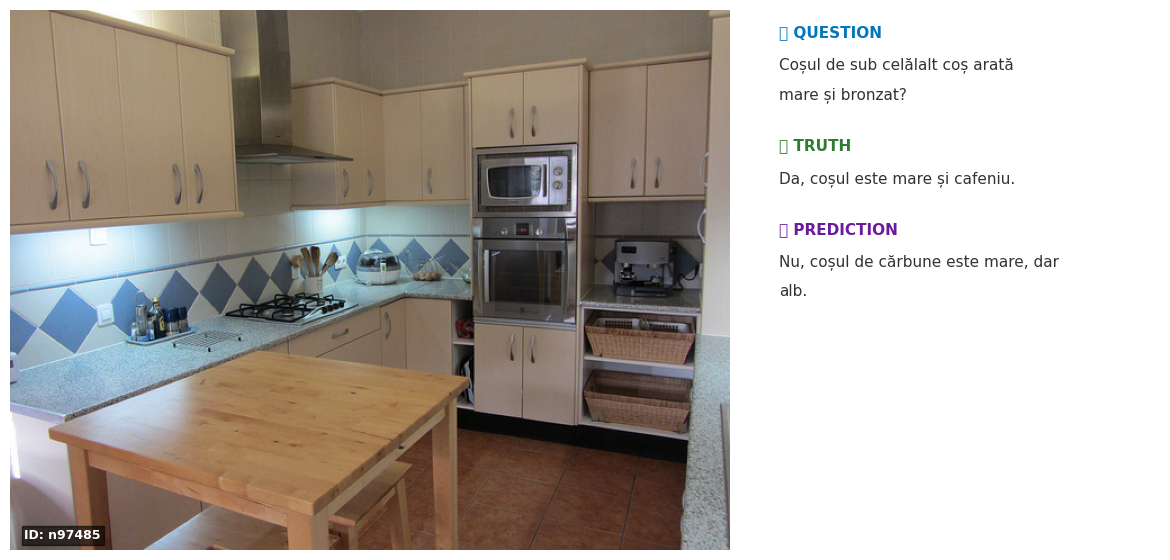

In [ ]:
import matplotlib.pyplot as plt
import textwrap
import random
import os

def visualize_compact_slide(image, question, gt_answer, prediction, image_id):
    """
    Creates a compact, slide-ready visualization with a large image
    and clearly readable, color-coded text.
    """
    # 1. Setup Figure (Standard Slide Ratio)
    # 12x6 is good for 16:9 slides. Width ratios give 65% to image.
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.8, 1]})
    ax_img, ax_txt = ax[0], ax[1]

    # Adjust spacing to be tight
    plt.subplots_adjust(wspace=0.05, left=0.02, right=0.98, top=0.95, bottom=0.05)

    # --- LEFT PANEL: IMAGE ---
    ax_img.imshow(image)
    ax_img.axis("off")
    # Small label inside the image (bottom left)
    ax_img.text(0.02, 0.02, f"ID: {image_id}", color="white", fontsize=9,
                transform=ax_img.transAxes, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=2))

    # --- RIGHT PANEL: TEXT ---
    ax_txt.axis("off")

    # Text Settings
    wrap_width = 35  # Tighter wrap for the narrower column
    wrapper = textwrap.TextWrapper(width=wrap_width)

    # Helper for adding text blocks
    def add_block(y, label, text, color, header_color):
        # 1. Header
        ax_txt.text(0.05, y, label, fontsize=11, fontweight='bold', color=header_color, transform=ax_txt.transAxes)
        y -= 0.06 # Gap after header

        # 2. Body Text (wrapped)
        lines = wrapper.wrap(text)
        for line in lines:
            ax_txt.text(0.05, y, line, fontsize=11, color='#333333', transform=ax_txt.transAxes)
            y -= 0.055 # Line height

        return y - 0.04 # Gap between sections

    # Start writing from top
    cur_y = 0.95

    # 1. Question (Blue Theme)
    cur_y = add_block(cur_y, "❓ QUESTION", question, "#E3F2FD", "#0277BD")

    # 2. Ground Truth (Green Theme)
    cur_y = add_block(cur_y, "📖 TRUTH", gt_answer, "#E8F5E9", "#2E7D32")

    # 3. Prediction (Purple/Dark Theme)
    cur_y = add_block(cur_y, "🤖 PREDICTION", prediction, "#F3E5F5", "#6A1B9A")

    # --- SAVE ---
    save_dir = "slide_results"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"slide_{image_id}.png")

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Slide image saved to: {save_path}")
    plt.show()

# ==========================================
# EXECUTE
# ==========================================

random_idx = random.randint(0, len(test_df) - 1)
row = test_df.iloc[random_idx]
img_id = str(row["imageId"])
ques = row["question"]
gt_ans = row.get("fullAnswer", row.get("gt_answer", "N/A"))

if img_id in image_cache:
    img = image_cache[img_id]
    pred_ans = run_inference(model, tokenizer, img, ques)

    visualize_compact_slide(img, ques, gt_ans, pred_ans, img_id)
else:
    print(f"⚠️ Image {img_id} not found.")

Loading image from: Untitled1.jpg...
Running inference...
Plotting result...


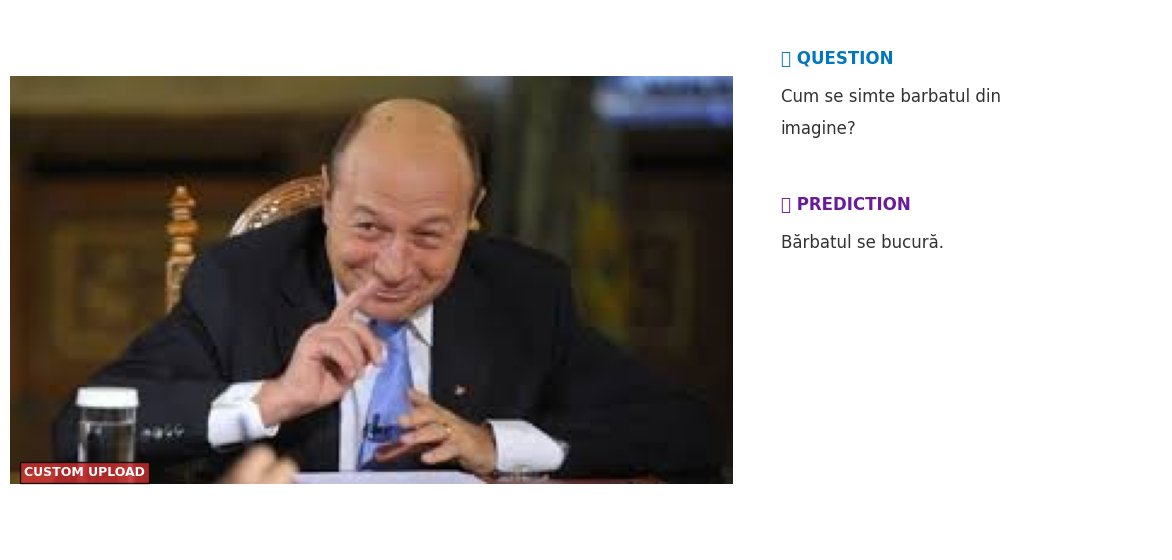

In [ ]:
import matplotlib.pyplot as plt
import textwrap
import requests
from PIL import Image
from io import BytesIO

# -----------------------------
# 1. Image Loading Helper
# -----------------------------
def load_image(path_or_url):
    """Loads an image from a local path or a URL."""
    try:
        if path_or_url.startswith("http"):
            response = requests.get(path_or_url)
            image = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            image = Image.open(path_or_url).convert("RGB")
        return image
    except Exception as e:
        print(f"❌ Error loading image: {e}")
        return None

# -----------------------------
# 2. Visualization (Adapted for Custom Inputs)
# -----------------------------
def visualize_custom_result(image, question, prediction):
    """
    Plots the image and result without a Ground Truth field.
    """
    # 1. Setup Figure
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.8, 1]})
    ax_img, ax_txt = ax[0], ax[1]

    # Tight layout settings
    plt.subplots_adjust(wspace=0.05, left=0.02, right=0.98, top=0.95, bottom=0.05)

    # --- LEFT PANEL: IMAGE ---
    ax_img.imshow(image)
    ax_img.axis("off")
    # Add a tag for "Custom Image"
    ax_img.text(0.02, 0.02, "CUSTOM UPLOAD", color="white", fontsize=9,
                transform=ax_img.transAxes, weight='bold',
                bbox=dict(facecolor='#D32F2F', alpha=0.8, pad=3))

    # --- RIGHT PANEL: TEXT ---
    ax_txt.axis("off")

    # Text Settings
    wrap_width = 30
    wrapper = textwrap.TextWrapper(width=wrap_width)

    def add_block(y, label, text, color, header_color):
        # Header
        ax_txt.text(0.05, y, label, fontsize=12, fontweight='bold', color=header_color, transform=ax_txt.transAxes)
        y -= 0.07
        # Body
        lines = wrapper.wrap(text)
        for line in lines:
            ax_txt.text(0.05, y, line, fontsize=12, color='#333333', transform=ax_txt.transAxes)
            y -= 0.06
        return y - 0.08 # Gap

    cur_y = 0.90

    # 1. Question
    cur_y = add_block(cur_y, "❓ QUESTION", question, "#E3F2FD", "#0277BD")

    # 2. Prediction (Given more space since there is no GT)
    cur_y = add_block(cur_y, "🤖 PREDICTION", prediction, "#F3E5F5", "#6A1B9A")

    plt.show()

# -----------------------------
# 3. Main Execution Function
# -----------------------------
def run_custom_inference(image_path, question, model, tokenizer):
    print(f"Loading image from: {image_path}...")
    image = load_image(image_path)

    if image is None:
        return

    print("Running inference...")
    # Ensure your run_inference function is available
    prediction = run_inference(model, tokenizer, image, question)

    print("Plotting result...")
    visualize_custom_result(image, question, prediction)

# ==========================================
# ✍️ ENTER YOUR CUSTOM DATA HERE
# ==========================================

# Option A: Use a URL
# MY_IMAGE = "https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg"

# Option B: Use a local file path
MY_IMAGE = "Untitled1.jpg"  # <--- Change this!

MY_QUESTION = "Cum se simte barbatul din imagine?" # <--- Change this!

# Run it!
run_custom_inference(MY_IMAGE, MY_QUESTION, model, tokenizer)